## 1. Librerías

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

## 2. Carga y Procesamiento de Datos

In [ ]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30


In [ ]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [ ]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [ ]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (61, 60)
Test shape: (16, 60)


## 4. Feature Selection - Selección de Top Features

In [ ]:
# Entrenar un modelo simple para obtener importancia de features
# Usamos Random Forest con configuración conservadora
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

# Obtener importancia de features
feature_importance = pd.Series(
    rf_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 15 features más importantes:")
print(feature_importance.head(15))


Top 15 features más importantes:
merval_cierre                      0.178296
merval_apertura_std20              0.157304
tc_mayorista_std20                 0.109336
emae_tendencia_ciclo_ma_5          0.103819
tc_minorista_std20                 0.070966
merval_cierre_std20                0.056455
gobernanza_mean                    0.052432
badlar_ma_5                        0.047308
merval_maximo                      0.032226
inflacion_lag2                     0.029369
sector_Educación_prop_true_lag1    0.020651
emae_tendencia_ciclo_lag2          0.015510
bonos_soberanos_mean_lag2          0.011427
m2_transaccional_pct3              0.010420
tasa_prestamos_personales_ma_3     0.008084
dtype: float64


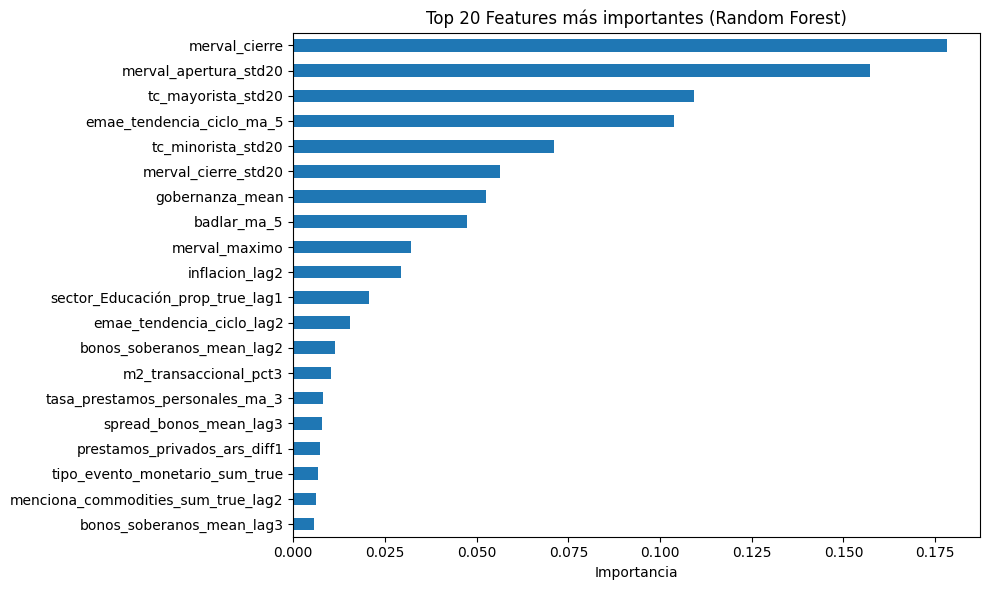

In [ ]:
# Visualizar importancia de features
plt.figure(figsize=(10, 6))
feature_importance.head(20).sort_values(ascending=True).plot(kind='barh')
plt.title('Top 20 Features más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [ ]:
# Seleccionar top N features
# Probamos con 12 y 15 features para ver cuál funciona mejor
N_FEATURES = 12  # Cambiar a 15 si se desea probar con más features

selected_features = feature_importance.head(N_FEATURES).index.tolist()

print(f"\nSeleccionadas {N_FEATURES} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Filtrar datasets
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

print(f"\nNuevo train shape: {X_train_fs.shape}")
print(f"Nuevo test shape: {X_test_fs.shape}")
print(f"\nNuevo ratio observaciones/features: {X_train_fs.shape[0] / X_train_fs.shape[1]:.2f}")


Seleccionadas 12 features:
1. merval_cierre
2. merval_apertura_std20
3. tc_mayorista_std20
4. emae_tendencia_ciclo_ma_5
5. tc_minorista_std20
6. merval_cierre_std20
7. gobernanza_mean
8. badlar_ma_5
9. merval_maximo
10. inflacion_lag2
11. sector_Educación_prop_true_lag1
12. emae_tendencia_ciclo_lag2

Nuevo train shape: (61, 12)
Nuevo test shape: (16, 12)

Nuevo ratio observaciones/features: 5.08


## 5. Optimización de Hiperparámetros con RandomizedSearchCV

In [ ]:
# Con 63 días de entrenamiento, usamos configuración balanceada:
# - n_splits=3: tres validaciones suficientes con pocos datos
# - test_size=8: ventana pequeña de validación
# - gap=1: separación mínima para maximizar datos disponibles

max_lag = 1
test_size = 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros balanceados para dataset pequeño
# Estrategia: permitir complejidad moderada pero con regularización
param_distributions = {
    "n_estimators": randint(150, 400),        # Suficientes árboles para estabilidad
    "max_depth": randint(8, 16),              # Profundidad moderada-alta
    "min_samples_split": randint(4, 12),      # Más flexible para aprovechar los datos
    "min_samples_leaf": randint(2, 6),        # Hojas pequeñas permitidas
    "max_features": uniform(0.4, 0.5),        # Rango centrado en valores típicos (0.4-0.9)
    "bootstrap": [True]
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,                               # Más iteraciones para explorar mejor
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [ ]:
search.fit(X_train_fs, y_train)

best_rf = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 99209.9042

Mejores hiperparámetros:
  - bootstrap: True
  - max_depth: 8
  - max_features: 0.8828160165372797
  - min_samples_leaf: 3
  - min_samples_split: 5
  - n_estimators: 158


## 6. Evaluación en Test Set

### 6.1. Test del mejor modelo

In [ ]:
y_pred = best_rf.predict(X_test_fs)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Holdout RMSE: 266736.7784
Holdout R²:   -8.7720
Error relativo (holdout): 12.24%


### 6.2. Visualización de predicciones

In [ ]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

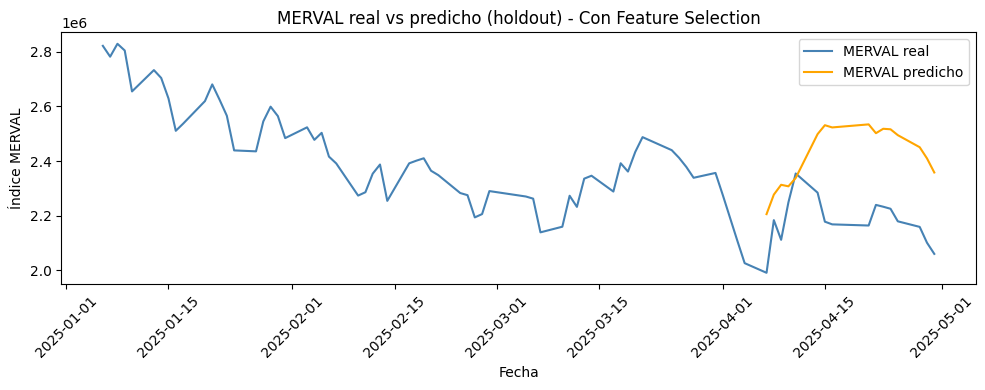

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout) - Con Feature Selection")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

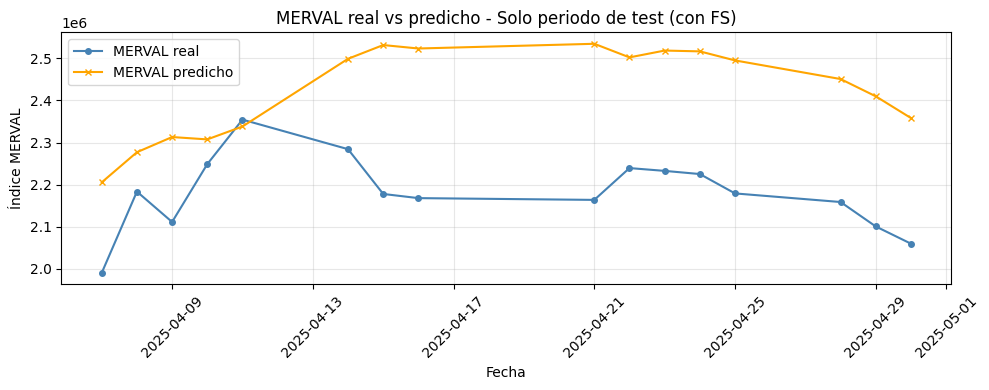

In [ ]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test (con FS)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

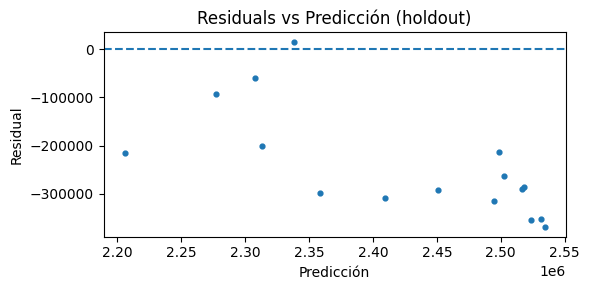

In [ ]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()

### 6.4. Importancia de variables (features seleccionadas)

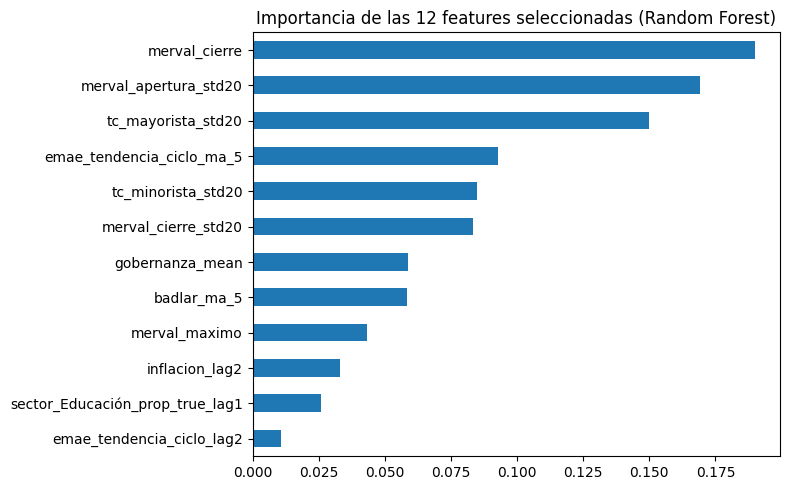

In [ ]:
# Importancia de las variables seleccionadas

imp = pd.Series(best_rf.feature_importances_, index=X_train_fs.columns).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8,5), title=f"Importancia de las {N_FEATURES} features seleccionadas (Random Forest)")
plt.tight_layout(); plt.show()

## 7. Conclusiones

Este modelo utiliza **feature selection** para reducir el número de variables de 60 a 12, abordando el problema de la maldición de la dimensionalidad. Utiliza el dataset con **variables extraídas del LLM** (dataset_llm_fs_top60_+2.csv).

### Resultados Principales

**Métricas de rendimiento:**
- **RMSE en CV**: 99,210
- **RMSE en Test**: 266,737
- **R² en Test**: -8.77
- **Error relativo**: 12.24%

**Configuración del modelo:**
- **Features utilizadas**: 12 (de 60 originales)
- **Ratio observaciones/features**: 5.08 (mejorado desde 1.02)
- **Observaciones de entrenamiento**: 61
- **Observaciones de test**: 16
- **Dataset**: Variables del LLM (análisis de noticias)

### Análisis del Desempeño

#### 1. Overfitting Severo Persistente

El modelo presenta **overfitting severo** a pesar de usar feature selection y variables del LLM:
- Gap CV→Test: +169% (RMSE casi triplica entre CV y Test)
- R² negativo (-8.77), indicando predicciones peores que un modelo baseline que predice la media
- Error relativo del 12.24%, alto para aplicaciones financieras

**Observación importante**: El CV RMSE (99,210) es el más bajo entre todos los modelos probados, sugiriendo que las variables del LLM con feature selection capturan mejor los patrones en validación cruzada. Sin embargo, esto no se traduce en buena generalización a test.

#### 2. Características del Dataset LLM

Este dataset tiene particularidades que afectan el modelado:
- **61 observaciones de entrenamiento** (2 menos que dataset_v2)
- Variables derivadas de **análisis de noticias con LLM** (sentimiento, menciones, impactos)
- Período: 2025-01-06 a 2025-04-30 (inicio más tardío por requerimientos de datos textuales)
- Incluye features de: gobernanza, impactos sectoriales, menciones de actores políticos/económicos

#### 3. Features Seleccionadas

El proceso de feature selection de Random Forest identificó las siguientes 12 variables como más importantes:
1. **merval_cierre** (valor de cierre del índice)
2. **merval_apertura_std20** (volatilidad de apertura)
3. **tc_mayorista_std20** (volatilidad tipo de cambio mayorista)
4. **emae_tendencia_ciclo_ma_5** (indicador de actividad económica)
5. **tc_minorista_std20** (volatilidad tipo de cambio minorista)
6. **merval_cierre_std20** (volatilidad del cierre)
7. **gobernanza_mean** (sentimiento sobre gobernanza - variable LLM)
8. **badlar_ma_5** (promedio móvil tasa BADLAR)
9. **merval_maximo** (valor máximo del índice)
10. **inflacion_lag2** (inflación rezagada)
11. **sector_Educación_prop_true_lag1** (proporción menciones sector educación - LLM)
12. **emae_tendencia_ciclo_lag2** (EMAE rezagado)

**Interpretación económica**: 
- **Volatilidad domina**: 5 de las 12 features son medidas de volatilidad (std20 de MERVAL y TC)
- **Variables LLM selectas**: Solo 2 variables del LLM fueron seleccionadas (gobernanza y sector educación), sugiriendo que Random Forest priorizó variables macroeconómicas tradicionales
- **Valores del MERVAL**: Cierre, apertura y máximo del índice tienen alta importancia
- **Indicadores monetarios y reales**: BADLAR, EMAE e inflación completan el set

**Contraste con LightGBM**: LightGBM seleccionó más variables del LLM (menciones Trump, INDEC, commodities, sectores), mientras Random Forest prefirió variables tradicionales con solo 2 del LLM.

#### 4. Comportamiento en Validación vs Test

La discrepancia CV-Test es significativa:
- Gap de +169% es alto, aunque menor que en algunos modelos sin feature selection
- El **excelente CV RMSE (99k)** no se traduce en buen desempeño en test (267k)
- Sugiere que el modelo aprende patrones específicos del período de entrenamiento que no generalizan

### Hiperparámetros Óptimos Encontrados

RandomizedSearchCV encontró la siguiente configuración (60 iteraciones):
- **n_estimators**: 158 (árboles en el bosque)
- **max_depth**: 8 (menos profundo que en dataset_v2)
- **max_features**: 0.88 (~10-11 features por split)
- **min_samples_split**: 5
- **min_samples_leaf**: 3
- **bootstrap**: True

**Análisis de hiperparámetros**: 
- Árboles menos profundos (8 vs 13 en dataset_v2) sugieren búsqueda de mayor regularización
- Mayor max_features (0.88) permite usar casi todas las 12 features disponibles
- Parámetros conservadores pero insuficientes para evitar overfitting con tan pocos datos

### Comparación CV vs Test: Análisis del Gap

El gap de +169% evidencia:
- **CV optimista**: El modelo logra RMSE de 99k en CV, el mejor de todos los modelos
- **Test realista**: En test, el RMSE salta a 267k, revelando overfitting
- **Folds no representativos**: Los 3 folds de CV no capturan la variabilidad del test set
- **Sensibilidad a partición**: Performance altamente dependiente de qué datos caen en train vs test

### Análisis de Variables del LLM en Random Forest

Observaciones sobre cómo Random Forest utiliza las variables del LLM:

**Selección conservadora**: 
- Solo 2 de 12 features seleccionadas provienen del LLM (gobernanza y sector educación)
- Random Forest priorizó variables tradicionales de volatilidad y valores del MERVAL
- Contrasta con LightGBM que seleccionó 8 variables del LLM

**Interpretación posible**:
- Random Forest con importancia basada en Gini puede subestimar variables categóricas/binarias típicas del LLM
- Las variables de sentimiento del LLM pueden tener relaciones más complejas que Random Forest no captura con pocos datos
- Variables de volatilidad (std20) dominan porque tienen alta varianza y splits claros

**Gobernanza como única variable LLM importante**:
- La variable de sentimiento sobre gobernanza logró alta importancia
- Sugiere que expectativas sobre gestión política son relevantes para predecir MERVAL
- Sector educación es menos interpretable en este contexto

### Limitaciones del Modelo

1. **Dataset demasiado pequeño**: 61 observaciones son claramente insuficientes para Random Forest
2. **Período temporal corto**: 4 meses no capturan variabilidad suficiente de regímenes de mercado
3. **Variables del LLM subutilizadas**: Random Forest seleccionó solo 2/60 variables del LLM originales
4. **Alta varianza**: Sensibilidad extrema a la partición train/test
5. **Ensemble débil**: Con bootstrap sobre 61 observaciones, los árboles son muy correlacionados
6. **Feature selection insuficiente**: Aunque mejora el ratio, no resuelve la escasez fundamental de datos

### Comparación con Objetivo Inicial

**Hipótesis inicial**: Feature selection + variables del LLM mejorarían generalización.

**Resultado parcial**:
- ✓ Mejor CV RMSE (99k) de todos los modelos
- ✓ Gap CV-Test (+169%) moderadamente mejor que algunos modelos
- ✗ Aún presenta R² profundamente negativo (-8.77)
- ✗ Error relativo inaceptable (12.24%)

**Conclusión**: Las variables del LLM aportan cierta información útil (reflejada en mejor CV), pero **no son suficientes** para resolver el problema fundamental de datos insuficientes.

### Conclusión Final

**El modelo Random Forest con feature selection y variables del LLM no es viable para este dataset.**

A pesar de:
- ✓ Incorporar variables de sentimiento y menciones del LLM
- ✓ Reducir features de 60 a 12 (ratio 1.02 → 5.08)
- ✓ Lograr el mejor CV RMSE (99k) entre todos los modelos
- ✓ Optimizar hiperparámetros con 60 iteraciones
- ✓ Usar regularización conservadora (max_depth=8)

El modelo presenta:
- ✗ R² de -8.77 (peor que predecir la media constante)
- ✗ Gap CV-Test de +169%
- ✗ Error relativo del 12.24%
- ✗ Performance en test inaceptable para aplicaciones prácticas

**Veredicto**: La limitación fundamental es la **cantidad absoluta de datos** (61 observaciones), no la dimensionalidad ni la calidad de las features. Random Forest requiere 100-300+ observaciones para funcionar adecuadamente. El excelente CV RMSE es engañoso y refleja overfitting, no capacidad predictiva real.

**Observación sobre variables del LLM**: Aunque prometedoras (logran mejor CV), Random Forest las subutiliza en la feature selection (solo 2 de 12). Con más datos, estas variables podrían mostrar mayor valor predictivo.